# KELOMPOK 1 EDA
1. Adawia Ananda (2106724883)
2. Fernaldy (2106706464)
3.  Myra Azzahra Putri Syah Indra (2106726844)
4. Nadia Sukesi Sianipar (2106700776)

#PRE-PROCESSING

# 1. Import Modul

Pada tahap ini akan di import modul-modul yang digunakan.

In [ ]:
import warnings; warnings.simplefilter('ignore')

try:
    import google.colab
    IN_COLAB = True
    !wget https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudataDDGsna.py
    !wget https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudataSNA.py
    !wget https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudata_sna.py
    !wget https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/network_unp2021.gexf
    !mkdir data
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/contoh.pdf
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/slang.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/stopwords_id.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/stopwords_en.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/kata_dasar.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/wn-ind-def.tab
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/wn-msa-all.tab
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/ind_SA.csv
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/all_indo_man_tag_corpus_model.crf.tagger

    !pip install --upgrade spacy python-crfsuite unidecode textblob sastrawi sklearn-pycrfsuite
    !pip install --upgrade unidecode twython tweepy beautifulsoup4 tika
    !python -m spacy download en
    !python -m spacy download xx
    !python -m spacy download en_core_web_sm
    nltk.download('popular')
except:
    IN_COLAB = False
    print("Running the code locally, please make sure all the python module versions agree with colab environment and all data/assets downloaded")

--2022-06-07 08:25:31--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudataDDGsna.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8030 (7.8K) [text/plain]
Saving to: ‘taudataDDGsna.py.2’

taudataDDGsna.py.2  100%[===================>]   7.84K  --.-KB/s    in 0s      

2022-06-07 08:25:31 (48.8 MB/s) - ‘taudataDDGsna.py.2’ saved [8030/8030]

--2022-06-07 08:25:31--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/taudataSNA.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2022-06-0

In [ ]:
"""
Installing Modules & getting the necessary files for "Google Colab"
Jika dijalankan di komputer lokal (PC/Laptop) silahkan unduh secara manual dan
lakukan instalasi module di terminal/command prompt
"""
print("Detecting environment: ", end=' ')
try:
    import google.colab
    IN_COLAB = True
    print("Running the code in Google Colab. Installing and downloading dependencies.\nPlease wait...")
    import nltk
    !wget https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/lib/taudataNlpTm.py
    !mkdir data
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/slang.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/stopwords_id.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/stopwords_en.txt
    !wget -P data/ https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/corpus_sederhana.txt
    !pip install unidecode textblob sastrawi
    nltk.download('popular')
except:
    IN_COLAB = False
    print("Running the code locally.")

Detecting environment:  Running the code in Google Colab. Installing and downloading dependencies.
Please wait...
--2022-06-07 07:32:52--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/lib/taudataNlpTm.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5686 (5.6K) [text/plain]
Saving to: ‘taudataNlpTm.py.1’

taudataNlpTm.py.1   100%[===================>]   5.55K  --.-KB/s    in 0s      

2022-06-07 07:32:52 (62.2 MB/s) - ‘taudataNlpTm.py.1’ saved [5686/5686]

mkdir: cannot create directory ‘data’: File exists
--2022-06-07 07:32:52--  https://raw.githubusercontent.com/taudata-indonesia/eLearning/master/data/slang.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...

In [ ]:
import tweepy as tw
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
import json, urllib.request, requests
import re
from urllib.request import Request, urlopen
from twython import TwythonStreamer
from bs4 import BeautifulSoup as bs

# 2. Menginisiasi CS,AK,At,dan CK

In [ ]:
Ck = 'TW_CONSUMER_KEY' # consumer_key
Cs = 'TW_CONSUMER_SECRET' # consumer_secret
At = 'TW_ACCESS_TOKEN' # access_token
As = 'TW_ACCESS_SECRET' # access_secret

'Done'

'Done'

Selanjutnya,didefenisikan consumer key, consumer secret key, access token key, access secret key agar twitter API bisa digunakan.

In [ ]:
auth = tw.auth.OAuthHandler(Ck, Cs)
auth.set_access_token(At, As)
api = tw.API(auth, wait_on_rate_limit=True)
usr_ = api.verify_credentials()
print('Welcome "{}" you are now connected to twitter server'.format(usr_.name))

Welcome "Aldy" you are now connected to twitter server


Di atas adalah hasil dari penginisiasian CS, AK, AT dan CK yang menandakan bahwa twitter API dapat digunakan.

#3. Mencari tweet (jumlah 2000 tweet) untuk hashtag analysis

In [ ]:
qry = 'Johnny Depp'
N = 2000 # jumlah N tweet "terkini" yang ingin diambil
Johnny = []
for post in tqdm(tw.Cursor(api.search_tweets, q=qry, lang='en', tweet_mode='extended').items(N)):
    Johnny.append(post)

"Done"

In [ ]:
qry = 'Amber Heard'
N = 2000 # jumlah N tweet "terkini" yang ingin diambil
Amber = []
for post in tqdm(tw.Cursor(api.search_tweets, q=qry, lang='en', tweet_mode='extended').items(N)):
    Johnny.append(post)

"Done"

#4. Mencari tweet (jumlah 2000 tweet)untuk dataframe

In [ ]:
Hashtag1 = 'Johnny Depp'
query = tw.Cursor(api.search_tweets,q=Hashtag1).items(2000)
tweets1= [{'Tweets1':tweet.text,'Timestamp':tweet.created_at}for tweet in query]
print(tweets1)

[{'Tweets1': 'Gonna have to mute Johnny Depp soon. The fangirling is out of hand', 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 27, tzinfo=datetime.timezone.utc)}, {'Tweets1': "RT @lailasbakwaas: to all the johnny depp fans who are sad the trial is over, don't be upset. he's being taken to court again next month fo…", 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 24, tzinfo=datetime.timezone.utc)}, {'Tweets1': 'it’s really weird to think that johnny depp will be playing at a concert in your obscure northern city in two weeks… https://t.co/LdWy6Vetkf', 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 21, tzinfo=datetime.timezone.utc)}, {'Tweets1': 'RT @atiebrahimi70: "Johnny Depp won, what does it mean for our society?"\n\nit means no matter your GENDER or who\'s backing you, if you LIE &amp;…', 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 18, tzinfo=datetime.timezone.utc)}, {'Tweets1': 'Me                                  Johnny Depp \n\n                     🤝🏻\n"I LOVED

In [ ]:
qry = 'Amber Heard'
N = 2000 # jumlah N tweet "terkini" yang ingin diambil
Amber = []
for post in tqdm(tw.Cursor(api.search_tweets, q=qry, lang='en', tweet_mode='extended').items(N)):
    Amber.append(post)

"Done"

2000it [00:35, 55.61it/s]


'Done'

In [ ]:
Hashtag2 = 'Amber Heard'
query = tw.Cursor(api.search_tweets, q=Hashtag2).items(2000)
tweets2 = [{'Tweets': tweet.text, 'Timestamp':tweet.created_at} for tweet in query]
print(tweets1)

[{'Tweets1': 'Gonna have to mute Johnny Depp soon. The fangirling is out of hand', 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 27, tzinfo=datetime.timezone.utc)}, {'Tweets1': "RT @lailasbakwaas: to all the johnny depp fans who are sad the trial is over, don't be upset. he's being taken to court again next month fo…", 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 24, tzinfo=datetime.timezone.utc)}, {'Tweets1': 'it’s really weird to think that johnny depp will be playing at a concert in your obscure northern city in two weeks… https://t.co/LdWy6Vetkf', 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 21, tzinfo=datetime.timezone.utc)}, {'Tweets1': 'RT @atiebrahimi70: "Johnny Depp won, what does it mean for our society?"\n\nit means no matter your GENDER or who\'s backing you, if you LIE &amp;…', 'Timestamp': datetime.datetime(2022, 6, 7, 7, 52, 18, tzinfo=datetime.timezone.utc)}, {'Tweets1': 'Me                                  Johnny Depp \n\n                     🤝🏻\n"I LOVED

#5. Mengubah bentuk data menjadi json dan dataframe.

In [ ]:
Johnny[0]._json

{'contributors': None,
 'coordinates': None,
 'created_at': 'Tue Jun 07 07:33:29 +0000 2022',
 'display_text_range': [0, 142],
 'entities': {'hashtags': [],
  'symbols': [],
  'urls': [{'display_url': 'youtu.be/71P8OIc0e4w',
    'expanded_url': 'https://youtu.be/71P8OIc0e4w',
    'indices': [108, 131],
    'url': 'https://t.co/4SGKRwHVQM'}],
  'user_mentions': [{'id': 10228272,
    'id_str': '10228272',
    'indices': [132, 140],
    'name': 'YouTube',
    'screen_name': 'YouTube'}]},
 'favorite_count': 0,
 'favorited': False,
 'full_text': 'Omg 😆 you are all right?!😂😂😂😂😂😂😂Jason Momoa Camille Vasquez cross examination in Johnny Depp Amber Heard... https://t.co/4SGKRwHVQM @YouTubeより',
 'geo': None,
 'id': 1534076062782525441,
 'id_str': '1534076062782525441',
 'in_reply_to_screen_name': None,
 'in_reply_to_status_id': None,
 'in_reply_to_status_id_str': None,
 'in_reply_to_user_id': None,
 'in_reply_to_user_id_str': None,
 'is_quote_status': False,
 'lang': 'en',
 'metadata': {'iso_lang

In [ ]:
Amber[0]._json

{'contributors': None,
 'coordinates': None,
 'created_at': 'Tue Jun 07 08:09:27 +0000 2022',
 'display_text_range': [0, 140],
 'entities': {'hashtags': [],
  'symbols': [],
  'urls': [],
  'user_mentions': [{'id': 1506887708857282560,
    'id_str': '1506887708857282560',
    'indices': [3, 19],
    'name': 'ThePatriach',
    'screen_name': 'GODisPatriarchy'}]},
 'favorite_count': 0,
 'favorited': False,
 'full_text': 'RT @GODisPatriarchy: The win of Johnny Depp over Amber Heard caused lot of men to rejoice, you know why?\n\nCos, men hardly get justice cos o…',
 'geo': None,
 'id': 1534085113545375745,
 'id_str': '1534085113545375745',
 'in_reply_to_screen_name': None,
 'in_reply_to_status_id': None,
 'in_reply_to_status_id_str': None,
 'in_reply_to_user_id': None,
 'in_reply_to_user_id_str': None,
 'is_quote_status': False,
 'lang': 'en',
 'metadata': {'iso_language_code': 'en', 'result_type': 'recent'},
 'place': None,
 'retweet_count': 5,
 'retweeted': False,
 'retweeted_status': {'

In [ ]:
df1 = pd.DataFrame.from_dict(tweets1)
df1.head()

,Tweets1,Timestamp
0,Gonna have to mute Johnny Depp soon. The fangi...,2022-06-07 07:52:27+00:00
1,RT @lailasbakwaas: to all the johnny depp fans...,2022-06-07 07:52:24+00:00
2,it’s really weird to think that johnny depp wi...,2022-06-07 07:52:21+00:00
3,"RT @atiebrahimi70: ""Johnny Depp won, what does...",2022-06-07 07:52:18+00:00
4,Me Johnny Dep...,2022-06-07 07:52:14+00:00


In [ ]:
df2 = pd.DataFrame.from_dict(tweets2)
df2.head()

,Tweets,Timestamp
0,RT @Ego_death18: I'll never forget the day Joh...,2022-06-07 08:26:10+00:00
1,RT @EmeraldGranites: People turned against Amb...,2022-06-07 08:26:10+00:00
2,RT @unafuentesita: no voy a defender a amber h...,2022-06-07 08:26:10+00:00
3,RT @RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,2022-06-07 08:26:09+00:00
4,"Anulan falsa campaña de apoyo a Amber Heard, q...",2022-06-07 08:26:03+00:00


#6. Melihat hasil dataframe pada 10 tweet terakhir

In [ ]:
df1.tail(10)

,Tweets1,Timestamp
1990,"RT @ThatUmbrella: Remember, listen and believe...",2022-06-07 06:34:22+00:00
1991,RT @JBernardez_: If Migos made a song about Jo...,2022-06-07 06:34:22+00:00
1992,RT @LisaBritton: Johnny Depp said in his state...,2022-06-07 06:34:20+00:00
1993,"My case is going online through the courts, be...",2022-06-07 06:34:19+00:00
1994,RT @FemCondition: Reminder Eve Barlow was thro...,2022-06-07 06:34:19+00:00
1995,RT @GODisPatriarchy: The win of Johnny Depp ov...,2022-06-07 06:34:17+00:00
1996,RT @TMZ: GoFundMe shuts down $1M Amber Heard f...,2022-06-07 06:34:13+00:00
1997,RT @lnfosSeriesFR: #PHOTOS Johnny Depp hier lo...,2022-06-07 06:34:12+00:00
1998,RT @bestofpacino: Al Pacino and Johnny Depp on...,2022-06-07 06:34:12+00:00
1999,GoFundMe anuló campaña falsa sobre Amber Heard...,2022-06-07 06:34:08+00:00


In [ ]:
df2.tail(10)

,Tweets,Timestamp
1990,RT @envienvienvi: @TMZ @TMZ what about other @...,2022-06-07 07:04:57+00:00
1991,Why the Internet Sided With Johnny Depp\nhttps...,2022-06-07 07:04:56+00:00
1992,RT @ThatUmbrella: Some charities taking taxpay...,2022-06-07 07:04:55+00:00
1993,"RT @BhargavaPriyash: Good Luck #Mangina , Who ...",2022-06-07 07:04:55+00:00
1994,RT @StefAlterNerd: No it wasn’t my best friend...,2022-06-07 07:04:54+00:00
1995,RT @RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,2022-06-07 07:04:50+00:00
1996,RT @DrProudman: For 11 words in a 2018 op-ed i...,2022-06-07 07:04:50+00:00
1997,RT @levinez: amber heard as aphrodite https://...,2022-06-07 07:04:50+00:00
1998,So Amber Heard doesn't have the money to pay. ...,2022-06-07 07:04:48+00:00
1999,"RT @laurarichards99: New Episode! ""78: The Cri...",2022-06-07 07:04:44+00:00


#7. Menghilangkan kata RT sehingga tidak akan mengganggu pada hasil analisis di aplikasi Voyant Tools.

In [ ]:
df1['Tweets1'] = df1['Tweets1'].str.strip("RT")

In [ ]:
df2['Tweets'] = df2['Tweets'].str.strip('RT')

#8. Melihat kolom dan baris dataframe

In [ ]:
df1.shape

(2000, 3)

In [ ]:
df2.shape

(2000, 3)

#9. Menandakan tweet yang berisikan kata yang diinginkan.

In [ ]:
depp_refs = ['JohnnyDepp','Johnny','Depp', 'Johnny Depp','Depp\'s']
heard_refs = ['AmberHeard','Amber','Heard','Amber Heard','Heard\'s']

def identify_subject(tweet,refs):
    flag=0
    for ref in refs:
        if tweet.find(ref) !=-1:
            flag=1
    return flag

df1['Depp']=df1['Tweets1'].apply(lambda x: identify_subject(x, depp_refs))
df2['Heard']=df2['Tweets'].apply(lambda x: identify_subject(x, heard_refs))

#8. Melihat dataframe setelah tweet ditandakan dengan angka 1 atau 0.

In [ ]:
df1[df1['Depp']==1]

,Tweets1,Timestamp,Depp
0,Gonna have to mute Johnny Depp soon. The fangi...,2022-06-07 07:52:27+00:00,1
3,"@atiebrahimi70: ""Johnny Depp won, what does i...",2022-06-07 07:52:18+00:00,1
4,Me Johnny Dep...,2022-06-07 07:52:14+00:00,1
5,"@belindapop Belinda y Amber Heard juntas, por ...",2022-06-07 07:52:11+00:00,1
6,@22Observer: @GellertDepp There are so many v...,2022-06-07 07:52:10+00:00,1
...,...,...,...
1995,@GODisPatriarchy: The win of Johnny Depp over...,2022-06-07 06:34:17+00:00,1
1996,@TMZ: GoFundMe shuts down $1M Amber Heard fun...,2022-06-07 06:34:13+00:00,1
1997,@lnfosSeriesFR: #PHOTOS Johnny Depp hier lors...,2022-06-07 06:34:12+00:00,1
1998,@bestofpacino: Al Pacino and Johnny Depp on t...,2022-06-07 06:34:12+00:00,1


In [ ]:
df2[df2['Heard']==1]

,Tweets,Timestamp,Heard
1,@EmeraldGranites: People turned against Amber...,2022-06-07 08:26:10+00:00,1
3,@RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,2022-06-07 08:26:09+00:00,1
4,"Anulan falsa campaña de apoyo a Amber Heard, q...",2022-06-07 08:26:03+00:00,1
6,@NotWithAmber: @abusehasnogende A group of DV...,2022-06-07 08:25:58+00:00,1
7,@PopCrave: Some jurors in the Johnny Depp v. ...,2022-06-07 08:25:55+00:00,1
...,...,...,...
1993,"@BhargavaPriyash: Good Luck #Mangina , Who of...",2022-06-07 07:04:55+00:00,1
1995,@RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,2022-06-07 07:04:50+00:00,1
1996,@DrProudman: For 11 words in a 2018 op-ed in ...,2022-06-07 07:04:50+00:00,1
1998,So Amber Heard doesn't have the money to pay. ...,2022-06-07 07:04:48+00:00,1


#11. Mendefinisikan tweet1 dan tweet2 agar bisa disave sebagai file json.

In [ ]:
tweet1 = [t._json for t in Johnny]
tweet2 = [t._json for t in Amber]
print(' Berhasil mendapatkan {} tweets'.format(len(tweet1)))
print(' Berhasil mendapatkan {} tweets'.format(len(tweet2)))

 Berhasil mendapatkan 2000 tweets
 Berhasil mendapatkan 2000 tweets


In [ ]:
def saveTweets(tweets, file='Tweets.json'): #in Json Format
    with open(file, 'w') as f:
        for t in tweets:
            try:
                f.write(json.dumps(t)+'\n')
            except:
                pass

#12. Menyimpan file json dari variabel tweet1 dan tweet2. (Untuk hashtag analysis)

In [ ]:
fileName1 = 'JohnnyDepp.json'
saveTweets(tweet1, file=fileName1)
print('Saved to '+fileName1)

Saved to JohnnyDepp.json


In [ ]:
fileName2 = 'AmberHeard.json'
saveTweets(tweet1, file=fileName2)
print('Saved to '+fileName2)

Saved to AmberHeard.json


#13. Menyimpan dataframe dengan berbentuk file csv dan txt. (Untuk sentiment analysis)

In [ ]:
df1.to_csv("JohnnyDepp.csv", encoding='utf8', index=False)

In [ ]:
df1.to_csv("JohnnyDepp.txt", sep = '\t')

In [ ]:
df2.to_csv("AmberHeard.csv", encoding='utf8', index=False)

In [ ]:
df2.to_csv("AmberHeard.txt", sep = '\t')

#14. Load tweet yang berbentuk file json serta melihat 5 tweet pertama

In [ ]:
def loadTweets(file='Tweets.json'):
    f=open(file,encoding='utf-8', errors ='ignore', mode='r')
    T=f.readlines();f.close()
    for i,t in enumerate(T):
        T[i] = json.loads(t.strip())
    return T

In [ ]:
Johnny1 = loadTweets(file=fileName1)
print('tweet pertama oleh "{}" : "{}"'.format(Johnny1[0]['user']['screen_name'],Johnny1[0]['full_text']))

tweet pertama oleh "risamarieee" : "Omg 😆 you are all right?!😂😂😂😂😂😂😂Jason Momoa Camille Vasquez cross examination in Johnny Depp Amber Heard... https://t.co/4SGKRwHVQM @YouTubeより"


In [ ]:
Amber1 = loadTweets(file=fileName2)
print('tweet pertama oleh "{}" : "{}"'.format(Amber1[0]['user']['screen_name'],Amber1[0]['full_text']))

tweet pertama oleh "risamarieee" : "Omg 😆 you are all right?!😂😂😂😂😂😂😂Jason Momoa Camille Vasquez cross examination in Johnny Depp Amber Heard... https://t.co/4SGKRwHVQM @YouTubeより"


In [ ]:
# Contoh mengambil hanya data tweet
D1 = [t['full_text'] for t in Johnny1]
D1[:5] # 5 tweet pertama

['Omg 😆 you are all right?!😂😂😂😂😂😂😂Jason Momoa Camille Vasquez cross examination in Johnny Depp Amber Heard... https://t.co/4SGKRwHVQM @YouTubeより',
 "RT @barstoolsports: After Destroying Amber Heard in Court, Johnny Depp's Lawyer Camille Vasquez is Reportedly Getting Flooded With Job Offe…",
 "RT @irem_yagmur_: You're gorgeous Johnny Depp. ❤️💘❤️\n#JohnnyDepp https://t.co/J87WQMBw4N",
 'RT @cocainecross: So lemme get this straight. He had a celebratory party BEFORE the verdict was announced. Partied with people like Kate Mo…',
 'Johnny depp https://t.co/eIaV6nlYbm']

In [ ]:
D2 = [t['full_text'] for t in Amber1]
D2[:5] # 5 tweet pertama

['Omg 😆 you are all right?!😂😂😂😂😂😂😂Jason Momoa Camille Vasquez cross examination in Johnny Depp Amber Heard... https://t.co/4SGKRwHVQM @YouTubeより',
 "RT @barstoolsports: After Destroying Amber Heard in Court, Johnny Depp's Lawyer Camille Vasquez is Reportedly Getting Flooded With Job Offe…",
 "RT @irem_yagmur_: You're gorgeous Johnny Depp. ❤️💘❤️\n#JohnnyDepp https://t.co/J87WQMBw4N",
 'RT @cocainecross: So lemme get this straight. He had a celebratory party BEFORE the verdict was announced. Partied with people like Kate Mo…',
 'Johnny depp https://t.co/eIaV6nlYbm']

#15. Membuat filter untuk hashtags analysis

In [ ]:
HTfilters = set(['follow', 'follow me'])
# modifikasi HTfilters sesuai data kamu
HT1 = {'hashtags':[]}
count = 0
getHashTags = re.compile(r"#(\w+)")
for i, d in tqdm(enumerate(D1)):
    hashtags = re.findall(getHashTags, d)
    if hashtags:
        TG = []
        for tag in hashtags:
            dTag = str(tag).strip().lower()
            if len(dTag)>2:
                add = True
                for f in HTfilters:
                    if f in dTag:
                        add=False; break
                if add:
                    TG.append('#'+dTag); count += 1
            HT1['hashtags'].append(TG)
print('Found {} number of hashtags'.format(count))

2000it [00:00, 259115.59it/s]

Found 627 number of hashtags


In [ ]:
HTfilters = set(['follow', 'follow me'])
# modifikasi HTfilters sesuai data kamu
HT2 = {'hashtags':[]}
count = 0
getHashTags = re.compile(r"#(\w+)")
for i, d in tqdm(enumerate(D2)):
    hashtags = re.findall(getHashTags, d)
    if hashtags:
        TG = []
        for tag in hashtags:
            dTag = str(tag).strip().lower()
            if len(dTag)>2:
                add = True
                for f in HTfilters:
                    if f in dTag:
                        add=False; break
                if add:
                    TG.append('#'+dTag); count += 1
            HT2['hashtags'].append(TG)
print('Found {} number of hashtags'.format(count))

2000it [00:00, 160295.96it/s]

Found 627 number of hashtags


#16. Membuat visualisasi apa saja hashtags yang ditemukan dan menyimpannya dengan bentuk file csv.

100%|██████████| 630/630 [00:00<00:00, 708991.55it/s]


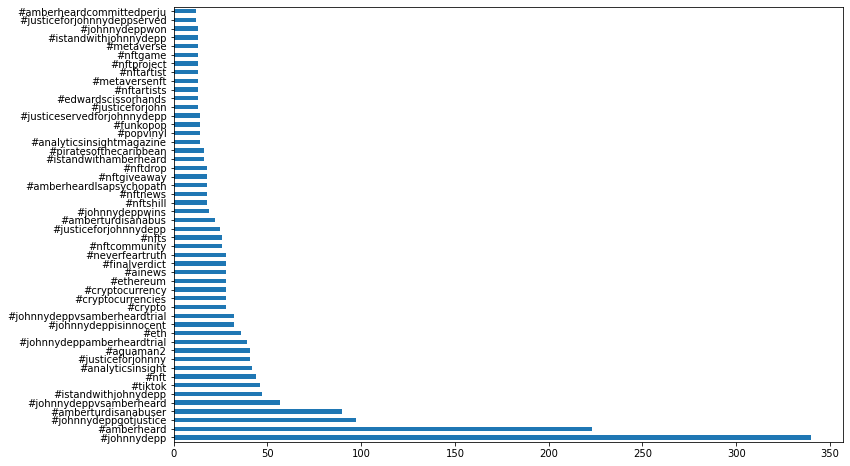

In [ ]:
N = 50 # Number of top frequent hashtags to be plotted

dtHT1 = [x for t in tqdm(HT1['hashtags']) for x in t] # any(h not in x for h in HTfilters)
dtHT1 = pd.Series(dtHT1)
dtHT1 = dtHT1.value_counts()
dtHT1 = dtHT1.sort_index()
dtHT1 = dtHT1.sort_values(ascending = False)
dtHT1.to_csv('JohnnyDepp_HashtagAnalysis.csv', encoding='utf8')
dtHT1 = dtHT1.iloc[:N]

p = dtHT1.plot(kind='barh', figsize=(12,8), legend = False)

100%|██████████| 630/630 [00:00<00:00, 149847.54it/s]


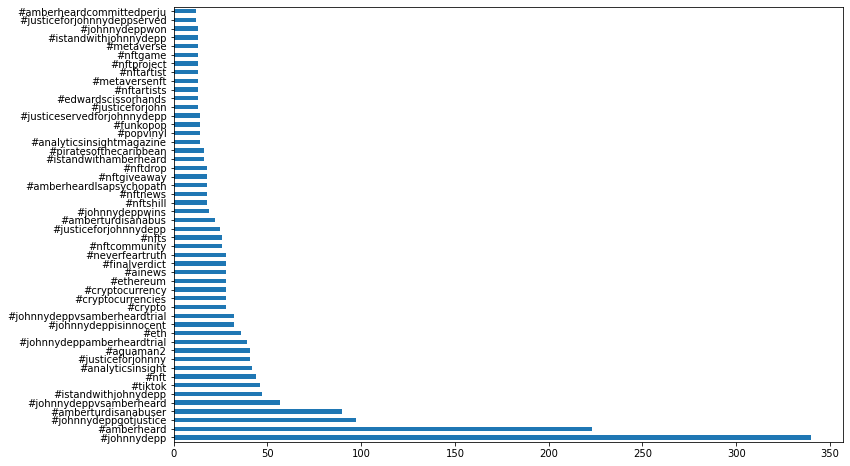

In [ ]:
N = 50 # Number of top frequent hashtags to be plotted

dtHT2 = [x for t in tqdm(HT2['hashtags']) for x in t] # any(h not in x for h in HTfilters)
dtHT2 = pd.Series(dtHT2)
dtHT2 = dtHT2.value_counts()
dtHT2 = dtHT2.sort_index()
dtHT2 = dtHT2.sort_values(ascending = False)
dtHT2.to_csv('AmberHeard_HashtagAnalysis.csv', encoding='utf8')
dtHT2 = dtHT2.iloc[:N]

p = dtHT2.plot(kind='barh', figsize=(12,8), legend = False)

#17. Mengimport modul untuk sentiment analysis dan membuat stopwords.

In [ ]:
#import stopwords

import nltk
from nltk.corpus import stopwords

#import textblob
from textblob import Word,TextBlob

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = stopwords.words('english')
custom_stopwords = ['RT', ['Johnny Depp','#Amber Heard']]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#18. Preprocess tweet ketika tweet tidak ada di variabel stopwords dan custom_stopwords lalu menambahkannya ke dataframe dengan header ‘Preprocessed Tweet’

In [ ]:
def preprocess_tweets(tweet,custom_stopwords):
    preprocessed_tweet = tweet
    preprocessed_tweet.replace('[^\w\s]','')
    preprocessed_tweet = " ".join(word for word in preprocessed_tweet.split() if word not in stop_words)
    preprocessed_tweet = " ".join(word for word in preprocessed_tweet.split() if word not in custom_stopwords)
    preprocessed_tweet = " ".join(Word(word).lemmatize() for word in preprocessed_tweet.split())
    return (preprocessed_tweet)

df1['Processed Tweet'] = df1['Tweets1'].apply(lambda x:preprocess_tweets(x,custom_stopwords))
df1.head()

,Tweets1,Timestamp,Depp,Processed Tweet
0,Gonna have to mute Johnny Depp soon. The fangi...,2022-06-07 07:52:27+00:00,1,Gonna mute Johnny Depp soon. The fangirling hand
1,@lailasbakwaas: to all the johnny depp fans w...,2022-06-07 07:52:24+00:00,0,@lailasbakwaas: johnny depp fan sad trial over...
2,it’s really weird to think that johnny depp wi...,2022-06-07 07:52:21+00:00,0,it’s really weird think johnny depp playing co...
3,"@atiebrahimi70: ""Johnny Depp won, what does i...",2022-06-07 07:52:18+00:00,1,"@atiebrahimi70: ""Johnny Depp won, mean society..."
4,Me Johnny Dep...,2022-06-07 07:52:14+00:00,1,"Me Johnny Depp 🤝🏻 ""I LOVED YOU FOR SO MANY FUC..."


In [ ]:
def preprocess_tweets(tweet,custom_stopwords):
    preprocessed_tweet = tweet
    preprocessed_tweet.replace('[^\w\s]','')
    preprocessed_tweet = " ".join(word for word in preprocessed_tweet.split() if word not in stop_words)
    preprocessed_tweet = " ".join(word for word in preprocessed_tweet.split() if word not in custom_stopwords)
    preprocessed_tweet = " ".join(Word(word).lemmatize() for word in preprocessed_tweet.split())
    return (preprocessed_tweet)

df2['Processed Tweet'] = df2['Tweets'].apply(lambda x:preprocess_tweets(x,custom_stopwords))
df2.head()

,Tweets,Timestamp,Heard,Processed Tweet
0,@Ego_death18: I'll never forget the day Johnn...,2022-06-07 08:26:10+00:00,0,@Ego_death18: I'll never forget day Johnny Dep...
1,@EmeraldGranites: People turned against Amber...,2022-06-07 08:26:10+00:00,1,"@EmeraldGranites: People turned Amber Heard, J..."
2,@unafuentesita: no voy a defender a amber hea...,2022-06-07 08:26:10+00:00,0,@unafuentesita: voy defender amber heard porqu...
3,@RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,2022-06-07 08:26:09+00:00,1,@RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg
4,"Anulan falsa campaña de apoyo a Amber Heard, q...",2022-06-07 08:26:03+00:00,1,"Anulan falsa campaña de apoyo Amber Heard, que..."


#19. Menghitung sentiment

Menghitung Polarity dan Subjectivity pada df1 dan menampilkan 4 data teratas.

In [ ]:
df1['polarity']=df1['Processed Tweet'].apply(lambda x: TextBlob(x).sentiment[0])
df1['subjectivity']=df1['Processed Tweet'].apply(lambda x: TextBlob(x).sentiment[1])

df1.head()

,Tweets1,Timestamp,Depp,Processed Tweet,polarity,subjectivity
0,Gonna have to mute Johnny Depp soon. The fangi...,2022-06-07 07:52:27+00:00,1,Gonna mute Johnny Depp soon. The fangirling hand,0.0000,0.0000
1,@lailasbakwaas: to all the johnny depp fans w...,2022-06-07 07:52:24+00:00,0,@lailasbakwaas: johnny depp fan sad trial over...,-0.2500,0.5000
2,it’s really weird to think that johnny depp wi...,2022-06-07 07:52:21+00:00,0,it’s really weird think johnny depp playing co...,-0.5000,1.0000
3,"@atiebrahimi70: ""Johnny Depp won, what does i...",2022-06-07 07:52:18+00:00,1,"@atiebrahimi70: ""Johnny Depp won, mean society...",-0.3125,0.6875
4,Me Johnny Dep...,2022-06-07 07:52:14+00:00,1,"Me Johnny Depp 🤝🏻 ""I LOVED YOU FOR SO MANY FUC...",0.2000,0.7000


Menghitung Polarity dan Subjectivity pada df2 dan menampilkan 4 data teratas.

In [ ]:
df2['polarity']=df2['Processed Tweet'].apply(lambda x: TextBlob(x).sentiment[0])
df2['subjectivity']=df2['Processed Tweet'].apply(lambda x: TextBlob(x).sentiment[1])

df2.head()

,Tweets,Timestamp,Heard,Processed Tweet,polarity,subjectivity
0,@Ego_death18: I'll never forget the day Johnn...,2022-06-07 08:26:10+00:00,0,@Ego_death18: I'll never forget day Johnny Dep...,0.0,0.0
1,@EmeraldGranites: People turned against Amber...,2022-06-07 08:26:10+00:00,1,"@EmeraldGranites: People turned Amber Heard, J...",0.4,1.0
2,@unafuentesita: no voy a defender a amber hea...,2022-06-07 08:26:10+00:00,0,@unafuentesita: voy defender amber heard porqu...,0.0,0.0
3,@RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,2022-06-07 08:26:09+00:00,1,@RVCJ_FB: Amber Heard! https://t.co/sl1NHS0LYg,0.0,0.0
4,"Anulan falsa campaña de apoyo a Amber Heard, q...",2022-06-07 08:26:03+00:00,1,"Anulan falsa campaña de apoyo Amber Heard, que...",0.0,0.0


Menggabungkan hasil Polarity dan Subjectivity dari df1 dan df2 pada satu tabel dengan menampilkan nilai mean,minimum,maximum,dan median.

In [ ]:
display(df1[df1['Depp']==1][['Depp','polarity','subjectivity']].groupby('Depp').agg([np.mean,np.max,np.min,np.median]))
df2[df2['Heard']==1][['Heard','polarity','subjectivity']].groupby('Heard').agg([np.mean,np.max,np.min,np.median])

polarity                  subjectivity                 
          mean amax amin median         mean amax amin median
Depp                                                         
1     0.056245  1.0 -1.0    0.0      0.25299  1.0  0.0    0.0

polarity                  subjectivity                 
           mean amax amin median         mean amax amin median
Heard                                                         
1      0.023171  1.0 -1.0    0.0     0.226366  1.0  0.0    0.0

Menampilkan visualisasi grafik polaritas dari Tagar Johnny Depp dan Amber Heard pada 10 tweets, 100 tweets, 500 tweets, 1000 tweets, 1500 tweets, serta 2000 tweets.

In [ ]:
depp10 = df1[df1['Depp']==1][['Timestamp','polarity']]
depp10 = depp10.sort_values(by='Timestamp',ascending=True)
depp10['MA Polarity']=depp10.polarity.rolling(10,min_periods=3).mean()

heard10 = df2[df2['Heard']==1][['Timestamp','polarity']]
heard10 = heard10.sort_values(by='Timestamp',ascending=True)
heard10['MA Polarity']=heard10.polarity.rolling(10,min_periods=3).mean()

In [ ]:
depp10.head()

,Timestamp,polarity,MA Polarity
1999,2022-06-07 06:34:08+00:00,0.000000,NaN
1998,2022-06-07 06:34:12+00:00,0.000000,NaN
1997,2022-06-07 06:34:12+00:00,0.000000,0.000000
1996,2022-06-07 06:34:13+00:00,0.000000,0.000000
1995,2022-06-07 06:34:17+00:00,0.254167,0.050833


In [ ]:
heard10.head()

,Timestamp,polarity,MA Polarity
1999,2022-06-07 07:04:44+00:00,0.170455,NaN
1998,2022-06-07 07:04:48+00:00,0.100000,NaN
1995,2022-06-07 07:04:50+00:00,0.000000,0.090152
1996,2022-06-07 07:04:50+00:00,0.000000,0.067614
1992,2022-06-07 07:04:55+00:00,0.130000,0.080091


# VISUALISASI

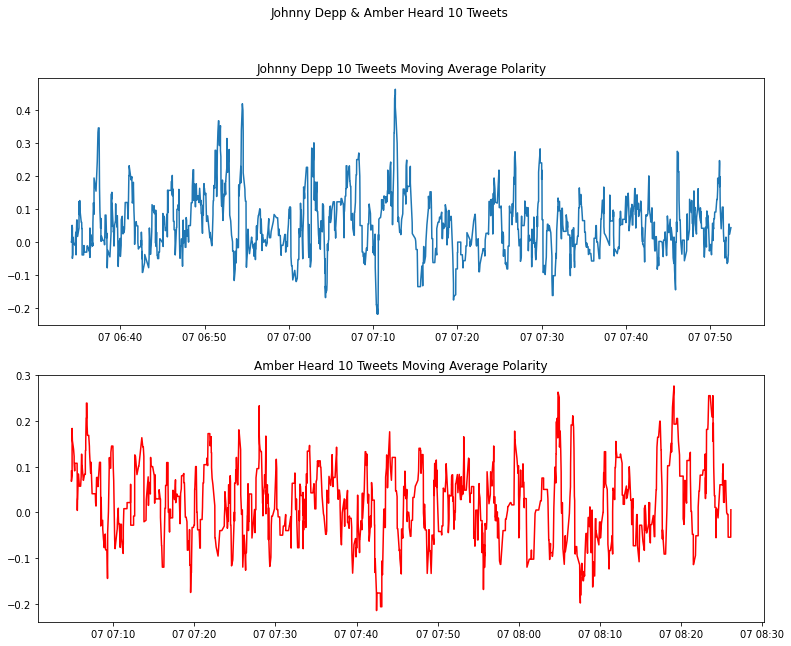

In [ ]:
fig,axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(depp10['Timestamp'],depp10['MA Polarity'])
axes[0].set_title("\n".join(['Johnny Depp 10 Tweets Moving Average Polarity']))
axes[1].plot(heard10['Timestamp'],heard10['MA Polarity'],color='red')
axes[1].set_title("\n".join(['Amber Heard 10 Tweets Moving Average Polarity']))
fig.suptitle('\n'.join(['Johnny Depp & Amber Heard 10 Tweets']),y=0.98)
plt.show()

In [ ]:
depp100 = df1[df1['Depp']==1][['Timestamp','polarity']]
depp100 = depp100.sort_values(by='Timestamp',ascending=True)
depp100['MA Polarity']=depp100.polarity.rolling(100,min_periods=3).mean()

heard100 = df2[df2['Heard']==1][['Timestamp','polarity']]
heard100 = heard100.sort_values(by='Timestamp',ascending=True)
heard100['MA Polarity']=heard100.polarity.rolling(100,min_periods=3).mean()

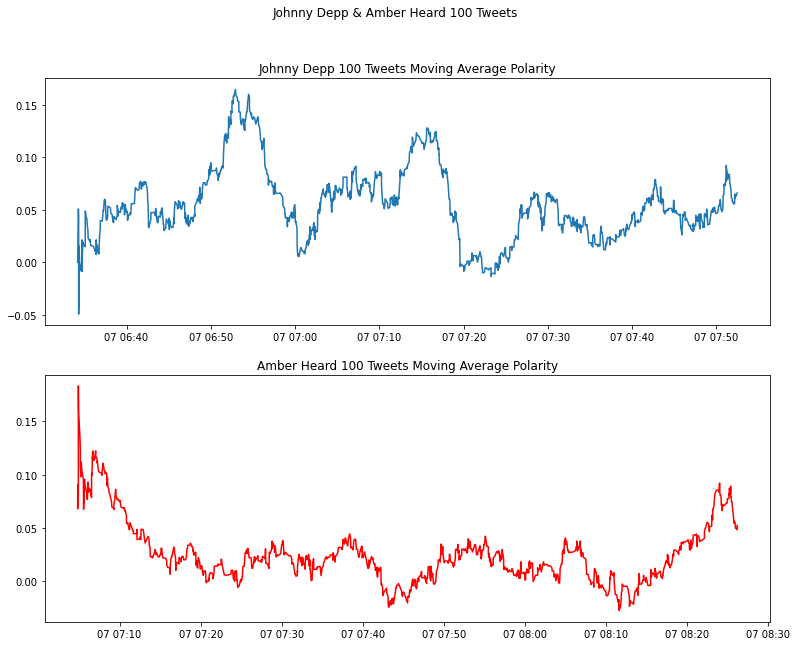

In [ ]:
fig,axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(depp100['Timestamp'],depp100['MA Polarity'])
axes[0].set_title("\n".join(['Johnny Depp 100 Tweets Moving Average Polarity']))
axes[1].plot(heard100['Timestamp'],heard100['MA Polarity'],color='red')
axes[1].set_title("\n".join(['Amber Heard 100 Tweets Moving Average Polarity']))
fig.suptitle('\n'.join(['Johnny Depp & Amber Heard 100 Tweets']),y=0.98)
plt.show()

In [ ]:
depp500 = df1[df1['Depp']==1][['Timestamp','polarity']]
depp500 = depp500.sort_values(by='Timestamp',ascending=True)
depp500['MA Polarity']=depp500.polarity.rolling(500,min_periods=3).mean()

heard500 = df2[df2['Heard']==1][['Timestamp','polarity']]
heard500 = heard500.sort_values(by='Timestamp',ascending=True)
heard500['MA Polarity']=heard500.polarity.rolling(500,min_periods=3).mean()

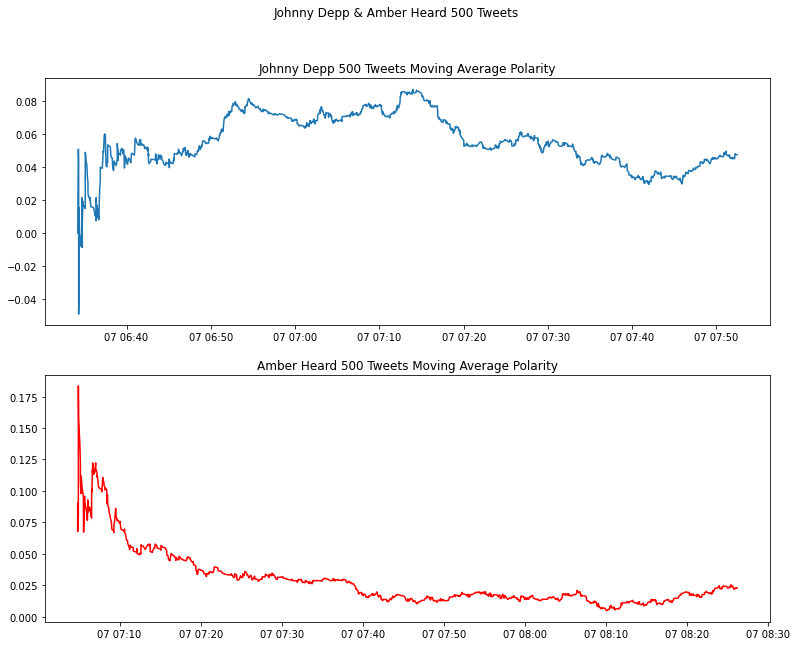

In [ ]:
fig,axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(depp500['Timestamp'],depp500['MA Polarity'])
axes[0].set_title("\n".join(['Johnny Depp 500 Tweets Moving Average Polarity']))
axes[1].plot(heard500['Timestamp'],heard500['MA Polarity'],color='red')
axes[1].set_title("\n".join(['Amber Heard 500 Tweets Moving Average Polarity']))
fig.suptitle('\n'.join(['Johnny Depp & Amber Heard 500 Tweets']),y=0.98)
plt.show()

In [ ]:
depp1000 = df1[df1['Depp']==1][['Timestamp','polarity']]
depp1000 = depp1000.sort_values(by='Timestamp',ascending=True)
depp1000['MA Polarity']=depp1000.polarity.rolling(1000,min_periods=3).mean()

heard1000 = df2[df2['Heard']==1][['Timestamp','polarity']]
heard1000 = heard1000.sort_values(by='Timestamp',ascending=True)
heard1000['MA Polarity']=heard1000.polarity.rolling(1000,min_periods=3).mean()

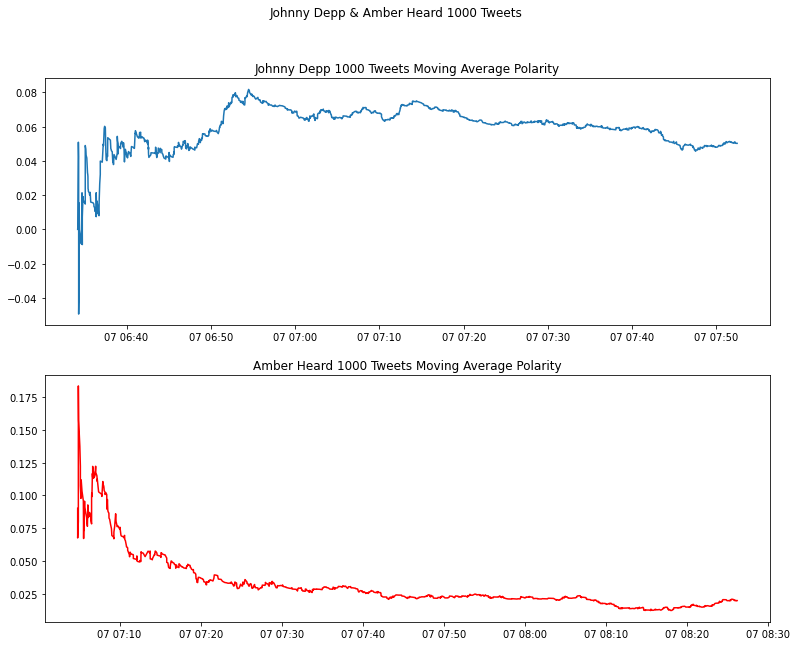

In [ ]:
fig,axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(depp1000['Timestamp'],depp1000['MA Polarity'])
axes[0].set_title("\n".join(['Johnny Depp 1000 Tweets Moving Average Polarity']))
axes[1].plot(heard1000['Timestamp'],heard1000['MA Polarity'],color='red')
axes[1].set_title("\n".join(['Amber Heard 1000 Tweets Moving Average Polarity']))
fig.suptitle('\n'.join(['Johnny Depp & Amber Heard 1000 Tweets']),y=0.98)
plt.show()

In [ ]:
depp1500 = df1[df1['Depp']==1][['Timestamp','polarity']]
depp1500 = depp1500.sort_values(by='Timestamp',ascending=True)
depp1500['MA Polarity']=depp1500.polarity.rolling(1500,min_periods=3).mean()

heard1500 = df2[df2['Heard']==1][['Timestamp','polarity']]
heard1500 = heard1500.sort_values(by='Timestamp',ascending=True)
heard1500['MA Polarity']=heard1500.polarity.rolling(1500,min_periods=3).mean()

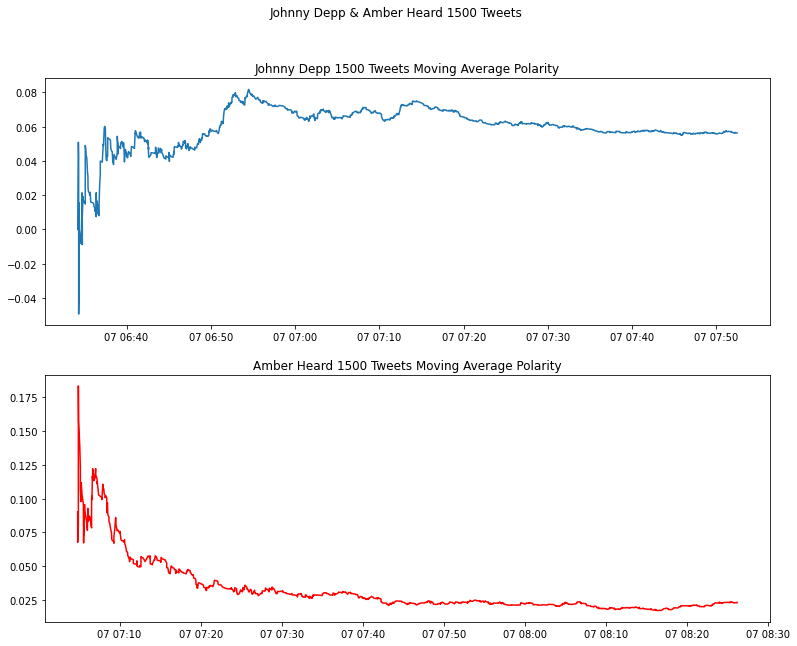

In [ ]:
fig,axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(depp1500['Timestamp'],depp1500['MA Polarity'])
axes[0].set_title("\n".join(['Johnny Depp 1500 Tweets Moving Average Polarity']))
axes[1].plot(heard1500['Timestamp'],heard1500['MA Polarity'],color='red')
axes[1].set_title("\n".join(['Amber Heard 1500 Tweets Moving Average Polarity']))
fig.suptitle('\n'.join(['Johnny Depp & Amber Heard 1500 Tweets']),y=0.98)
plt.show()

In [ ]:
depp2000 = df1[df1['Depp']==1][['Timestamp','polarity']]
depp2000 = depp2000.sort_values(by='Timestamp',ascending=True)
depp2000['MA Polarity']=depp2000.polarity.rolling(2000,min_periods=3).mean()

heard2000 = df2[df2['Heard']==1][['Timestamp','polarity']]
heard2000 = heard2000.sort_values(by='Timestamp',ascending=True)
heard2000['MA Polarity']=heard2000.polarity.rolling(2000,min_periods=3).mean()

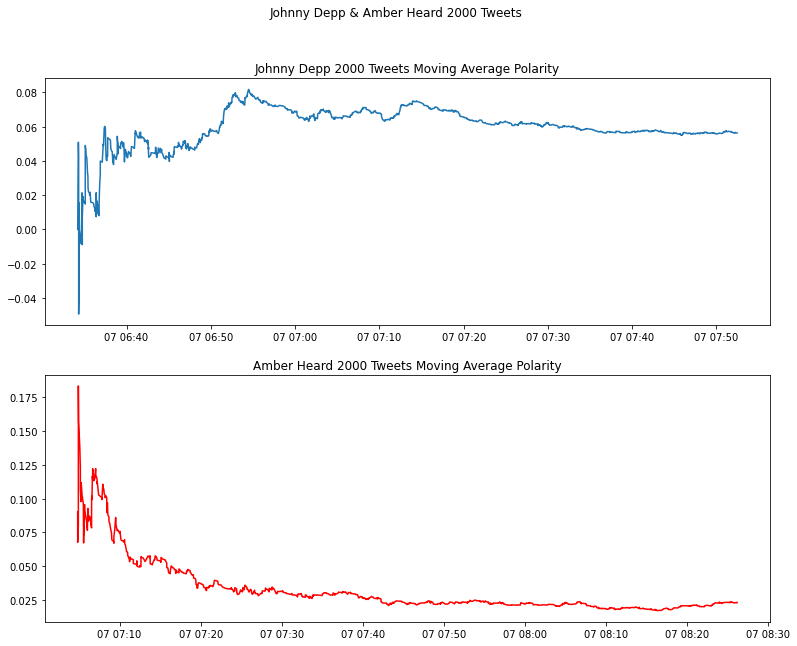

In [ ]:
fig,axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(depp2000['Timestamp'],depp2000['MA Polarity'])
axes[0].set_title("\n".join(['Johnny Depp 2000 Tweets Moving Average Polarity']))
axes[1].plot(heard2000['Timestamp'],heard2000['MA Polarity'],color='red')
axes[1].set_title("\n".join(['Amber Heard 2000 Tweets Moving Average Polarity']))
fig.suptitle('\n'.join(['Johnny Depp & Amber Heard 2000 Tweets']),y=0.98)
plt.show()

#KESIMPULAN

Dapat ditarik kesimpulan, bahwa Amber Heard lebih awal mendapatkan dukungan dan simpati dari publik, tapi setelah berjalannya waktu terungkap fakta-fakta tentang kasus ini yang mendukung alibi dari Johnny Depp, sehingga Johnny Depp didukung oleh publik. Hal ini mempengaruhi opini publik untuk lebih mendukung kemenangan Johnny Depp untuk kasus ini.
